<a href="https://colab.research.google.com/github/amaansadat/SRDT/blob/main/KFoldEntropy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape: (569, 31)

Class distribution (0 = malignant, 1 = benign):
target
1    357
0    212
Name: count, dtype: int64

Accuracy for each of the 10 folds:
  Fold 1: 0.9298
  Fold 2: 0.9649
  Fold 3: 0.9123
  Fold 4: 0.8947
  Fold 5: 0.9298
  Fold 6: 0.8596
  Fold 7: 0.9649
  Fold 8: 0.9825
  Fold 9: 0.9474
  Fold 10: 0.9643

Mean Accuracy : 0.9350
Std Deviation  : 0.0359

Overall Classification Report (aggregated across folds):
              precision    recall  f1-score   support

   malignant       0.91      0.92      0.91       212
      benign       0.95      0.95      0.95       357

    accuracy                           0.93       569
   macro avg       0.93      0.93      0.93       569
weighted avg       0.94      0.93      0.94       569

Overall Accuracy (aggregated across folds): 0.9350


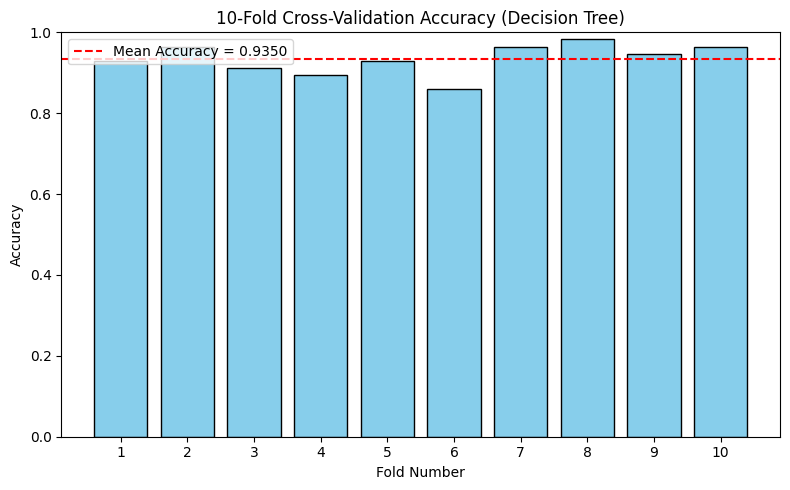

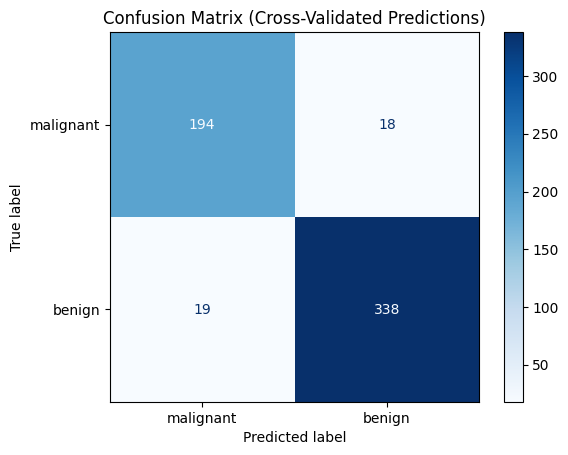

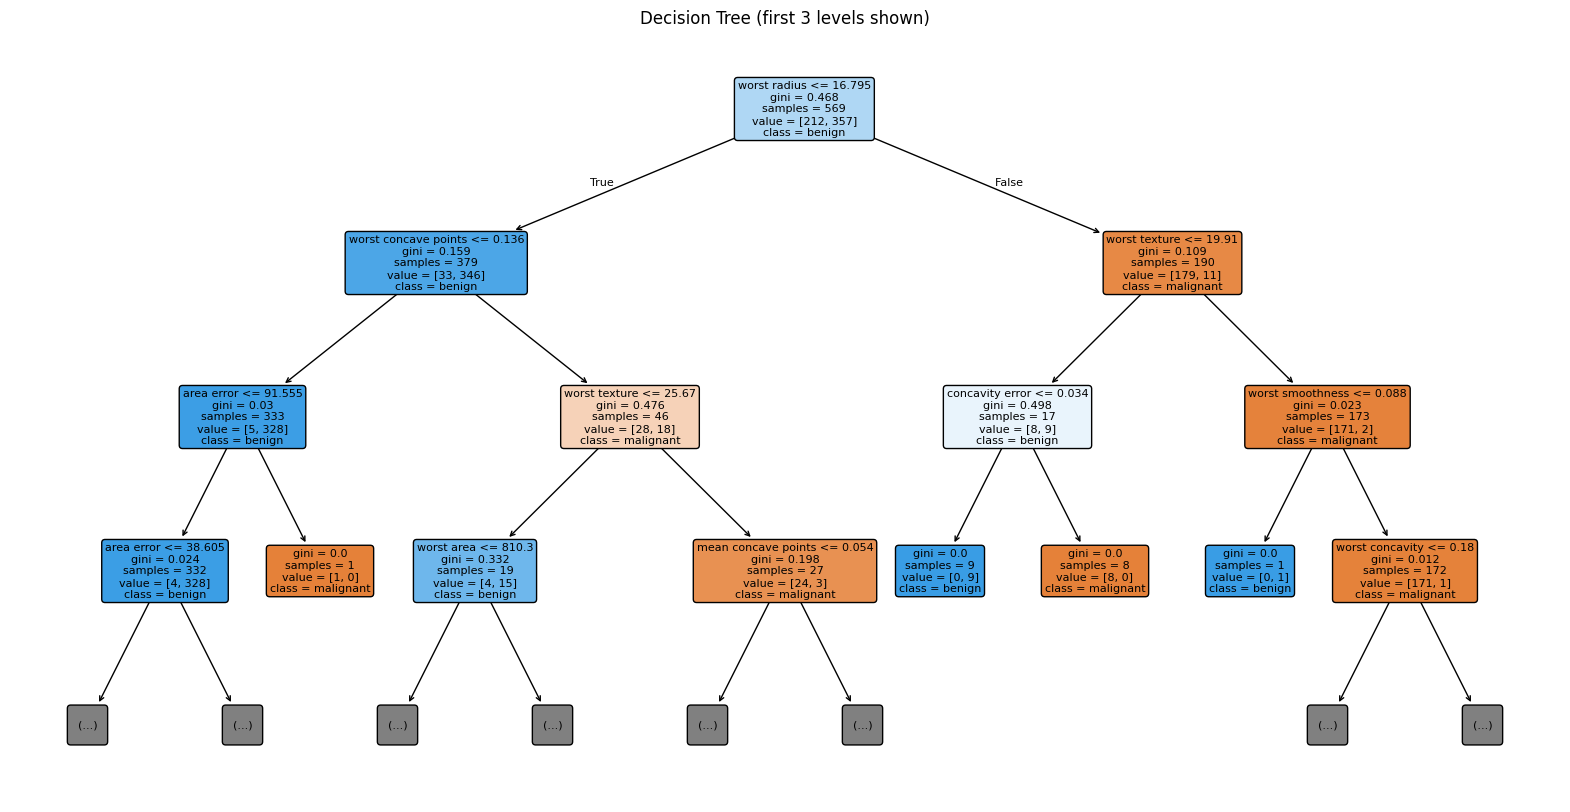

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


data = load_breast_cancer()

X = data.data
y = data.target

df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

print("Dataset shape:", df.shape)
print("\nClass distribution (0 = malignant, 1 = benign):")
print(df['target'].value_counts())

df.head()

dt_model = DecisionTreeClassifier(random_state=42)

k = 10
kf = KFold(n_splits=k, shuffle=True, random_state=42)

cv_scores = cross_val_score(dt_model, X, y, cv=kf, scoring='accuracy')

print(f"\nAccuracy for each of the {k} folds:")
for i, score in enumerate(cv_scores, start=1):
    print(f"  Fold {i}: {score:.4f}")

print(f"\nMean Accuracy : {cv_scores.mean():.4f}")
print(f"Std Deviation  : {cv_scores.std():.4f}")

y_pred = cross_val_predict(dt_model, X, y, cv=kf)

print("\nOverall Classification Report (aggregated across folds):")
print(classification_report(y, y_pred, target_names=data.target_names))

overall_acc = accuracy_score(y, y_pred)
print(f"Overall Accuracy (aggregated across folds): {overall_acc:.4f}")

plt.figure(figsize=(8, 5))
plt.bar(range(1, k + 1), cv_scores, color='skyblue', edgecolor='black')
plt.axhline(cv_scores.mean(), color='red', linestyle='--',
            label=f'Mean Accuracy = {cv_scores.mean():.4f}')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy')
plt.title(f'{k}-Fold Cross-Validation Accuracy (Decision Tree)')
plt.xticks(range(1, k + 1))
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (Cross-Validated Predictions)")
plt.show()

from sklearn.tree import plot_tree

dt_model.fit(X, y)

plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    max_depth=3,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree (first 3 levels shown)")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Parameters to tune
param_grid = {
    'criterion': ['entropy'],
    'max_depth': [2,4,6],
    'min_samples_split': [2, 5,10,20],
    'min_samples_leaf': [1, 2]
}

# Grid Search
grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=10,
    scoring='accuracy'
)

grid.fit(X, y)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid.best_score_)

Best Parameters:
{'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Cross Validation Accuracy:
0.9402882205513784


In [ ]:

best_model = grid.best_estimator_


best_model.fit(X, y)


train_pred = best_model.predict(X)


train_accuracy = accuracy_score(y, train_pred)

print("Training Accuracy:", train_accuracy)

Training Accuracy: 0.984182776801406
